# Logistic regression without using the conjunctive rules feature

## Imports

In [1]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from heart_failure.dataset import split_data
from heart_failure.features import get_fe_pipeline
from heart_failure.modeling.models import build_lr_pipeline
from heart_failure.modeling.train import optuna_search, lr_space
from heart_failure.config.modeling import CV_SPLITS, OPTUNA_N_TRIALS, CV_SCORING, F_BETA_THRESHOLD, MIN_RECALL
from heart_failure.config.config import INTERIM_DATA_DIR, HEART_DISEASE, SEX, PROCESSED_DATA_DIR
from heart_failure.config.features import TEST_SIZE, RANDOM_STATE, VAL_SIZE
from heart_failure.reports import print_best_params
from heart_failure.modeling.evaluate import get_metrics, log_metrics, find_best_threshold
from heart_failure.modeling.predict import predict_by_threshold
from heart_failure.plots import plot_pr_curve

2026-06-26 11:44:47.945 | INFO     | heart_failure.config.config:<module>:11 - PROJ_ROOT path is: D:\heart_failure


In [2]:
MODEL_NAME = "logistic_regression_without_conj_feature"
mlflow.set_experiment(f"heart_failure")

<Experiment: artifact_location='file:D:/heart_failure/notebooks/mlruns/1', creation_time=1781534399229, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781534399229, lifecycle_stage='active', name='heart_failure', tags={}, trace_location=None, workspace='default'>

In [3]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")
rem_columns = pd.read_csv(PROCESSED_DATA_DIR / "remaining_cols.csv")
rem_columns = rem_columns.squeeze().to_list()
rem_columns.remove("remainder__conjunctive_rules")

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

## Training

In [ ]:
fe_pipeline = get_fe_pipeline()
study, model = optuna_search(
    X_train,
    y_train,
    model_builder=build_lr_pipeline,
    param_space=lr_space,
    n_trials=OPTUNA_N_TRIALS,
    n_splits=CV_SPLITS,
    scoring=CV_SCORING,
    random_state=RANDOM_STATE,
    fe_pipeline=fe_pipeline,
    rem_columns=rem_columns,
)

In [6]:
print_best_params(study)

Best parameters: {'model__solver': 'liblinear', 'model__C': 0.079116015005508, 'model__max_iter': 389, 'model__tol': 4.6194074033948e-05, 'model__l1_ratio': 0}
Best score: 0.93350


In [7]:
lr = model.named_steps["model"]
weights = pd.Series(lr.coef_.ravel(), index=rem_columns)
weights.sort_values(key=abs, ascending=False)

remainder__Oldpeak_Cholesterol_ST_Slope_te    1.007317
target_encoder__ChestPainType                 0.681925
binary_encoder__Sex                           0.453413
binary_encoder__FastingBS                     0.426076
binary_encoder__ExerciseAngina                0.413515
binarizer__MaxHR                             -0.246761
remainder__Oldpeak                            0.219363
binarizer__Cholesterol                        0.204871
binarizer__Age                                0.098090
dtype: float64

The cv score remained virtually unchanged (compared to the model with the existing feature).

### Threshold searching

In [8]:
y_val_proba = model.predict_proba(X_val)[:, 1]
best_threshold = find_best_threshold(y_val, y_val_proba, MIN_RECALL)
best_threshold

np.float64(0.15160529871715264)

## Scores

In [9]:
print("Train metrics")
y_train_proba = model.predict_proba(X_train)[:, 1]
y_train_pred = predict_by_threshold(model, X_train)
train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
train_metrics

Train metrics


precision    0.882514
recall       0.907303
fpr          0.148789
pr_auc       0.940136
dtype: float64

In [10]:
print("Validate metrics")
y_val_pred = predict_by_threshold(model, X_val, best_threshold)
val_metrics = get_metrics(y_val, y_val_pred, y_val_proba)
val_metrics

Validate metrics


precision    0.710145
recall       1.000000
fpr          0.512821
pr_auc       0.933806
dtype: float64

The metrics are slightly worse than those of the previous logistic regression. But this difference is not very noticeable; conjunctive_rules does not have such an effect on the model.

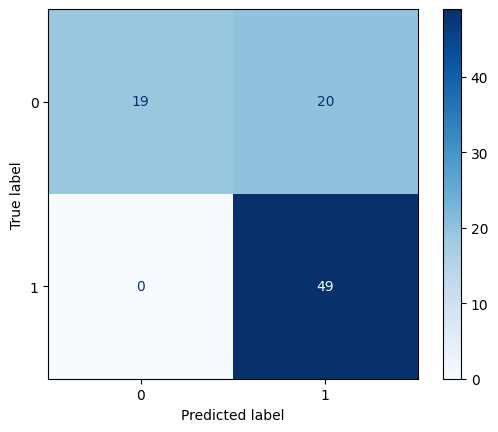

In [11]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, cmap="Blues")
plt.show()

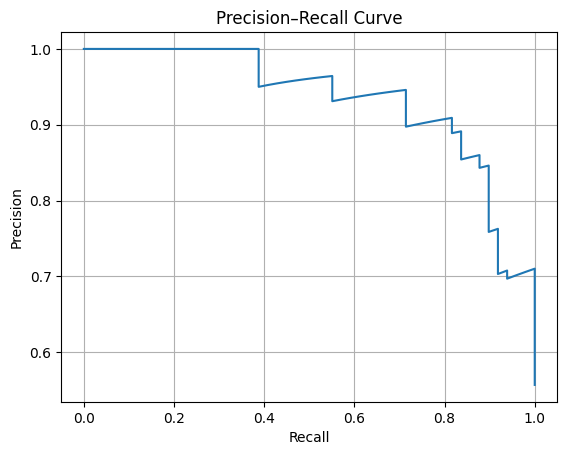

In [12]:
plot_pr_curve(y_val, y_val_proba)

In [13]:
print("Test metrics")
y_test_pred = predict_by_threshold(model, X_test, best_threshold)
y_test_proba = model.predict_proba(X_test)[:, 1]
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)
test_metrics

Test metrics


precision    0.706294
recall       0.990196
fpr          0.512195
pr_auc       0.936769
dtype: float64

In [ ]:
with mlflow.start_run(run_name=MODEL_NAME) as run:
    mlflow.log_param("model", MODEL_NAME)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("val_size", VAL_SIZE)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("cv_splits", CV_SPLITS)
    mlflow.log_param("optuna_n_trials", OPTUNA_N_TRIALS)
    mlflow.log_param("remaining_columns", rem_columns)
    mlflow.log_param("f_beta_threshold", F_BETA_THRESHOLD)
    mlflow.log_param("proba_threshold", best_threshold)

    mlflow.sklearn.log_model(sk_model=model, name=MODEL_NAME)

    log_metrics(train_metrics, "train_")
    log_metrics(val_metrics, "val_")
    log_metrics(test_metrics, "test_")